# 01 - EDA : IEEE-CIS Fraud Detection

**Étape CRISP-DM : Data Understanding**

Objectif de ce notebook :
1. Charger `train_transaction.csv` (590 540 lignes x 394 colonnes) sans saturer la RAM
2. Fusionner avec `train_identity.csv`
3. Visualiser le déséquilibre des classes (fraude vs non-fraude)

Contrainte : le fichier en float64/int64 natif dépasse la RAM disponible sur ce poste.
Stratégie retenue : lecture par chunks de 50 000 lignes avec downcast float32/int32 à la volée.

In [1]:
import gc
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = os.path.join("..", "data", "raw")
TRANSACTION_PATH = os.path.join(DATA_DIR, "train_transaction.csv")
IDENTITY_PATH = os.path.join(DATA_DIR, "train_identity.csv")
CHUNK_SIZE = 50_000

sns.set_theme(style="whitegrid")

## Cellule 2 - Chargement chunké avec downcast mémoire

On lit le CSV par blocs de 50 000 lignes. Sur chaque bloc :
- les colonnes `float64` sont converties en `float32`
- les colonnes entières sont converties en `int32` (ou plus petit si possible)

Si malgré cette optimisation la RAM est encore insuffisante (`MemoryError`), on bascule
automatiquement sur un échantillon de 100 000 lignes (`nrows=100_000`) pour l'EDA.
Cette approche est documentée et assumée : à ce stade (exploration), un échantillon
représentatif suffit ; le pipeline d'entraînement final (module `src/pipeline.py`)
traitera le dataset complet via un chargement chunké + agrégation incrémentale, sans
jamais matérialiser l'intégralité du DataFrame en mémoire si ce n'est pas nécessaire.

In [2]:
def downcast_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    float_cols = chunk.select_dtypes(include=["float64"]).columns
    chunk[float_cols] = chunk[float_cols].astype(np.float32)

    int_cols = chunk.select_dtypes(include=["int64"]).columns
    for col in int_cols:
        chunk[col] = pd.to_numeric(chunk[col], downcast="integer")

    return chunk


def load_transactions_chunked(path: str, chunksize: int = CHUNK_SIZE) -> pd.DataFrame:
    chunks = []
    for i, chunk in enumerate(pd.read_csv(path, chunksize=chunksize)):
        chunk = downcast_chunk(chunk)
        chunks.append(chunk)
        print(f"Chunk {i + 1} charge : {len(chunk):,} lignes (cumul {sum(len(c) for c in chunks):,})")

    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    return df


FALLBACK_NROWS = 100_000

try:
    df_transaction = load_transactions_chunked(TRANSACTION_PATH)
    print(f"\nChargement complet reussi : {df_transaction.shape}")
except MemoryError:
    print(f"MemoryError sur le chargement complet -> fallback nrows={FALLBACK_NROWS:,} pour l'EDA")
    df_transaction = pd.read_csv(TRANSACTION_PATH, nrows=FALLBACK_NROWS)
    df_transaction = downcast_chunk(df_transaction)
    print(f"Chargement partiel (echantillon EDA) : {df_transaction.shape}")

mem_mb = df_transaction.memory_usage(deep=True).sum() / 1024**2
print(f"Memoire occupee par df_transaction : {mem_mb:.1f} Mo")

Chunk 1 charge : 50,000 lignes (cumul 50,000)


Chunk 2 charge : 50,000 lignes (cumul 100,000)


Chunk 3 charge : 50,000 lignes (cumul 150,000)


Chunk 4 charge : 50,000 lignes (cumul 200,000)


Chunk 5 charge : 50,000 lignes (cumul 250,000)


...

Chunk 10 charge : 50,000 lignes (cumul 500,000)


Chunk 11 charge : 50,000 lignes (cumul 550,000)


Chunk 12 charge : 40,540 lignes (cumul 590,540)



Chargement complet reussi : (590540, 394)


Memoire occupee par df_transaction : 1203.2 Mo


## Cellule 3 - Fusion avec `train_identity.csv` et déséquilibre des classes

In [3]:
df_identity = pd.read_csv(IDENTITY_PATH)
df_identity = downcast_chunk(df_identity)

df = df_transaction.merge(df_identity, on="TransactionID", how="left")
print(f"Shape apres fusion : {df.shape}")
print(f"Taux de couverture identity : {df['DeviceType'].notna().mean():.1%}")

del df_transaction, df_identity
gc.collect()

Shape apres fusion : (590540, 434)
Taux de couverture identity : 23.8%


0

Repartition des classes :
  Non-fraude (0) : 569,877 (96.50%)
  Fraude     (1) : 20,663 (3.50%)
  Ratio de desequilibre : 1:28


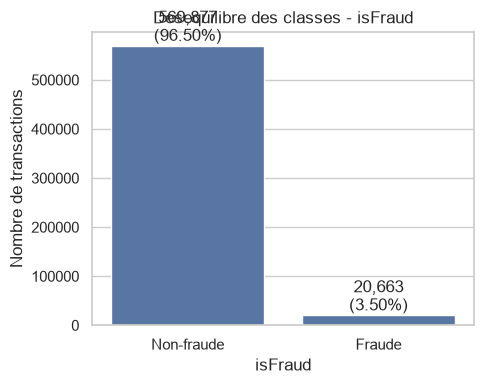

In [4]:
class_counts = df["isFraud"].value_counts()
class_pct = df["isFraud"].value_counts(normalize=True) * 100

print("Repartition des classes :")
print(f"  Non-fraude (0) : {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"  Fraude     (1) : {class_counts[1]:,} ({class_pct[1]:.2f}%)")
print(f"  Ratio de desequilibre : 1:{class_counts[0] / class_counts[1]:.0f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=ax)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(["Non-fraude", "Fraude"])
ax.set_ylabel("Nombre de transactions")
ax.set_title("Desequilibre des classes - isFraud")
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v:,}\n({class_pct.iloc[i]:.2f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()